In [9]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import copy
sys.path.append('../..')
from cpm.generators.wrapper import MetaSignalDetectionWrapper
from cpm.models.signal_detection import MetaSignalDetectionHelper, MetaSignalDetectionModel
from cpm.optimisation import minimise, DifferentialEvolution, FminBound, Bads
from cpm.applications.MetacognitionSDT import metacognitionSDT_initparams
from cpm.generators.meta_simulator import MetaSignalDetectionSimulator
from cpm.hierarchical import EmpiricalBayes

In [10]:
# nR_S1 = [36, 24, 17, 20, 10, 12, 9, 2]
# nR_S2 = [1, 4, 10, 11, 19, 18, 28, 39]
# # nR_S1 = [40, 36, 24, 17, 20, 10, 12, 9, 2, 1]
# # nR_S2 = [1, 1, 4, 10, 11, 19, 18, 28, 39, 40]
# nbins = 4

# binned_data = {
#     'nR_S1': np.array(nR_S1),
#     'nR_S2': np.array(nR_S2),
# }

In [11]:
comparison = pd.read_csv("/home/mavoeh/projects/tue002-metacognition-independece/data/processed/SpaceObserver_summary_merged.csv")
data = pd.read_csv('SpaceObserver_cpm_processed.csv')
userids = pd.Series(data['subject'].unique()).isin(comparison['user_id'])
existing_ppts = userids[userids].index.tolist()
print(f"{len(existing_ppts)} participants:", existing_ppts)
# exclude ppts where no KDE of confidence can be computed
# exclude_ppts = []
# for ppt in existing_ppts:
#     ppt_conf = data[data['ppt'] == ppt]['confidence']
#     ppt_stim = data[data['ppt'] == ppt]['stimulus']
#     ppt_resp = data[data['ppt'] == ppt]['response']
#     for S, R in zip([0,0,1,1], [0,1,0,1]):
#         try:
#             kde = gaussian_kde(ppt_conf[(ppt_stim == S) & (ppt_resp == R)])
#         except:
#             exclude_ppts.append(ppt)
#             break
# valid_ppts_kde = [int(p) for p in np.setdiff1d(existing_ppts, exclude_ppts)]

4716 participants: [2, 4, 7, 8, 10, 11, 13, 14, 15, 16, 18, 20, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 77, 78, 79, 82, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 132, 133, 134, 136, 137, 138, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 232, 233, 234, 235, 237, 238, 239, 240, 241, 242, 243, 244, 24

In [12]:
# select_ppts = valid_ppts_kde
select_ppts = existing_ppts
np.random.seed(42)
select_ppts = np.random.choice(select_ppts, size=len(select_ppts), replace=False).astype(int)
select_ppts = select_ppts[:100]
# select_ppts =  select_ppts[:]
data = data[data['ppt'].isin(select_ppts)]
# data = data.sort_values(by=['subject'])

ppt_to_userid = {p: s for p, s in zip(data['ppt'].unique(), comparison['user_id'])}
userid_to_ppt = {s: p for p, s in ppt_to_userid.items()}

In [13]:
nbins = 4

ptdata = np.zeros((len(select_ppts), 2, 2*nbins))
t1c1s = np.zeros(len(select_ppts))
d1s = np.zeros(len(select_ppts))
params, d1, t1c1, data_pandas, constraints, helper = metacognitionSDT_initparams(data=data, nbins=nbins, apply_adjustment=True, ppt_identifier="ppt")
ptdata[:,0,:], ptdata[:,1,:] = helper.nR_S1, helper.nR_S2
t1c1s = t1c1
d1s = d1
for ppt in select_ppts:
    params[ppt].t2c1.prior = 'uniform'

In [14]:
import torch as tc
from cpm.optimisation.pytorchopt import PtAdam
print(tc.cuda.is_available())
import os
print(os.environ.get("CUDA_VISIBLE_DEVICES"))

adam = PtAdam(parameters=params[ppt], data=ptdata, lr=0.2, t1c1s=t1c1s, d1s=d1s, number_of_starts=50, maxiters=1000)
adam.run(patience = 20, tolerance = 1e-2)
tc_results = adam.export()

False
None
Iteration 0
Loss: 247.00167520391307
Iteration 1
Loss: 215.57502706463683
Iteration 2
Loss: 198.69034675574758
Iteration 3
Loss: 185.44104272572747
Iteration 4
Loss: 174.29827214111342
Iteration 5
Loss: 164.14406665816531
Iteration 6
Loss: 157.22939520398603
Iteration 7
Loss: 152.22480407024824
Iteration 8
Loss: 147.61974359673926
Iteration 9
Loss: 144.13225608446345
Iteration 10
Loss: 141.66382125981517
Iteration 11
Loss: 139.65214720995652
Iteration 12
Loss: 138.1872771482222
Iteration 13
Loss: 137.1114831170806
Iteration 14
Loss: 136.2132713174677
Iteration 15
Loss: 135.2125542285876
Iteration 16
Loss: 134.64911493067106
Iteration 17
Loss: 133.9909386389574
Iteration 18
Loss: 133.36859818921235
Iteration 19
Loss: 132.92629312060146
Iteration 20
Loss: 132.52257362515826
Iteration 21
Loss: 132.08118350464386
Iteration 22
Loss: 131.67855121058858
Iteration 23
Loss: 131.36521980491696
Iteration 24
Loss: 131.0865489748724
Iteration 25
Loss: 130.82916609777556
Iteration 26
Loss

In [15]:
display(tc_results.round(2))

,d1,t1c1,meta_d,t2c1_0,t2c1_1,t2c1_2,t2c1_3,t2c1_4,t2c1_5,nLL
0,1.20,-0.12,-0.14,-1.18,-0.68,-0.26,0.34,0.65,1.10,113.06
1,1.24,-0.11,0.68,-1.06,-0.46,-0.23,0.41,0.90,1.16,107.97
2,1.00,0.04,2.00,-1.54,-0.90,-0.37,0.41,0.83,1.54,102.23
3,1.18,0.15,1.14,-1.44,-0.82,-0.37,0.31,0.73,1.25,110.22
4,1.10,0.11,1.23,-1.61,-0.74,-0.46,0.27,0.80,1.13,105.94
...,...,...,...,...,...,...,...,...,...,...
95,1.04,-0.17,0.14,-0.86,-0.53,-0.22,0.29,0.53,0.85,208.73
96,1.19,0.06,0.95,-1.42,-0.98,-0.34,0.18,0.48,1.14,106.14
97,1.20,-0.11,1.14,-1.17,-0.62,-0.31,0.44,0.88,1.48,108.61
98,1.32,0.46,0.16,-1.30,-0.74,-0.39,0.24,0.54,0.97,111.24


In [16]:
def model(parameters):
    msd = MetaSignalDetectionModel(nbins=nbins, d1=parameters.d1.value, t1c1=parameters.t1c1.value, meta_d1=parameters.meta_d1, t2c1=parameters.t2c1)
    output = {
        "nbins": nbins,
        "dependent": msd.t2_probs(),
    }
    return output

In [ ]:
def fit(nbins):

    print("Fitting model with nbins = ", nbins)

    params, d1, t1c1, data_pandas, constraints, helper = metacognitionSDT_initparams(data=data, nbins=nbins, apply_adjustment=True, ppt_identifier="ppt")

    def model(parameters):

        msd = MetaSignalDetectionModel(nbins=nbins, d_prime=parameters.d1.value, t1c1=parameters.t1c1.value, meta_d=parameters.meta_d1, t2c1=parameters.t2c1)
        output = {
            "nbins": nbins,
            "dependent": msd.compute(),
        }
        return output
        
    wrapper = MetaSignalDetectionWrapper(model=model, data=data_pandas, parameters=params)

    fit = FminBound(
        model=wrapper,  # Wrapper class with the model we specified from before
        data=data_pandas,  # the data as a list of dictionaries
        minimisation=minimise.LogLikelihood.multiproduct,
        parallel=True,
        prior=False,
        ppt_identifier="ppt",
        display=False,
        number_of_starts=5,
        # everything below is optional and passed directly to the scipy implementation of the optimiser
        approx_grad=True,
        constraints=constraints,
        verbose=False,
    )

    fit.optimise()

    # hierarchy = EmpiricalBayes(optimiser=fit, chain=4, iteration=20)
    # hierarchy.optimise()
    # print(hierarchy.hyperparameters)
    hierarchy = None


    ppt_subject_mapping = data[["ppt", "subject"]].drop_duplicates().reset_index(drop=True)
    results = fit.export()
    results["ppt"] = ppt_subject_mapping["ppt"]
    results["subject"] = ppt_subject_mapping["subject"]
    results["fit_d1"] = [param.d1.value for param in params.values()]
    results["fit_t1c1"] = [param.t1c1.value[0] for param in params.values()]
    results.rename(columns={"x_0": "fit_meta_d"}, inplace=True)
    results["fit_M_ratio"] = results["fit_meta_d"] / results["fit_d1"]

    return results, wrapper, helper, params, hierarchy

In [18]:
# res = fit(4)
# res = res.merge(comparison, left_on="subject", right_on="user_id")
# display(res[['subject', 'fit_d1', 'model_d1', 'fit_meta_d', 'model_meta_d', 'fit_M_ratio', 'model_M_ratio']])

In [19]:
nbins_list = [4]
# number of ppts that appear both in select_participants and comparison
nppts = len(set(data["subject"]).intersection(set(comparison["user_id"])))

columns = ['subject', 'nbins', 'ppt', 'fit_d1', 'model_d1', 'fit_t1c1', 'fit_meta_d', 'model_meta_d', 'fit_M_ratio', 'model_M_ratio', 'fun_0']
all_columns = columns.copy()
for i in range(1,2*max(nbins_list)-1):
    all_columns.append(f't2c1_{i}')
total_results = {}
for idx, nbins in enumerate(nbins_list):
    results, wrapper, helper, params, hierarchy = copy.deepcopy(fit(nbins))
    comparison = comparison[comparison["user_id"].isin(results["subject"])]
    nbins_df = pd.DataFrame(nbins, index = range(nppts), columns = ['nbins'])
    results = results.merge(comparison, left_on="subject", right_on="user_id")
    results = results.join(nbins_df)
    t2c1_names = [f't2c1_{i}' for i in range(1, 2*nbins-1)]
    xstrings = [f"x_{i}" for i in range(1, 2*nbins-1)]
    results_columns = columns + xstrings
    select_columns = columns + t2c1_names
    results.rename(columns=dict(zip(xstrings, t2c1_names)), inplace=True)
    total_results[nbins] = results[select_columns]
total_results = pd.concat(total_results.values(), ignore_index=True)
for var in ['d1', 'meta_d', 'M_ratio']:
    total_results[f'diff_{var}'] = total_results[f'fit_{var}'] - total_results[f'model_{var}']
    total_results[f'rel_diff_{var}'] = total_results[f'diff_{var}'] / total_results[f'model_{var}']

# display(total_results[['ppt', 'fit_d1', 'model_d1', 'fit_meta_d', 'model_meta_d', 'fit_M_ratio', 'model_M_ratio', 'fun_0']])
# display(total_results[['ppt', 'fit_t1c1', 't2c1_1', 't2c1_2', 't2c1_3', 't2c1_4', 't2c1_5', 't2c1_6']])
# display(total_results[['ppt', 'diff_d1', 'diff_meta_d', 'diff_M_ratio', 'rel_diff_d1', 'rel_diff_meta_d', 'rel_diff_M_ratio']])

Fitting model with nbins =  4


In [16]:
display(total_results[["fit_d1", "fit_t1c1", "fit_meta_d", "fun_0"]].round(2))

,fit_d1,fit_t1c1,fit_meta_d,fun_0
0,1.27,0.14,1.53,106.45
1,1.14,-0.07,0.48,221.10
2,1.20,-0.12,0.82,108.96
3,1.31,0.35,0.16,105.96
4,1.23,-0.35,0.91,106.00
5,1.06,-0.06,0.67,89.17
6,1.21,0.02,1.09,214.26
7,1.24,-0.11,-0.01,110.66
8,1.32,-0.38,2.05,100.79
9,1.30,0.13,0.86,110.65


In [41]:
# # print fully
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(hierarchy.hyperparameters)
display(hierarchy.hyperparameters)

,chain,iteration,parameter,mean,sd,lme,reject
0,0,1,meta_d1,0.882978,0.721836,-6783.088465,True
0,0,1,t2c1_arrayelem_0,-1.190905,0.365756,-6783.088465,True
0,0,1,t2c1_arrayelem_1,-0.696827,0.220273,-6783.088465,True
0,0,1,t2c1_arrayelem_2,-0.326767,0.137989,-6783.088465,True
0,0,1,t2c1_arrayelem_3,0.343768,0.153370,-6783.088465,True
...,...,...,...,...,...,...,...
0,3,20,t2c1_arrayelem_1,-0.696826,0.220273,-6783.088357,True
0,3,20,t2c1_arrayelem_2,-0.326767,0.137989,-6783.088357,True
0,3,20,t2c1_arrayelem_3,0.343768,0.153370,-6783.088357,True
0,3,20,t2c1_arrayelem_4,0.721155,0.248778,-6783.088357,True


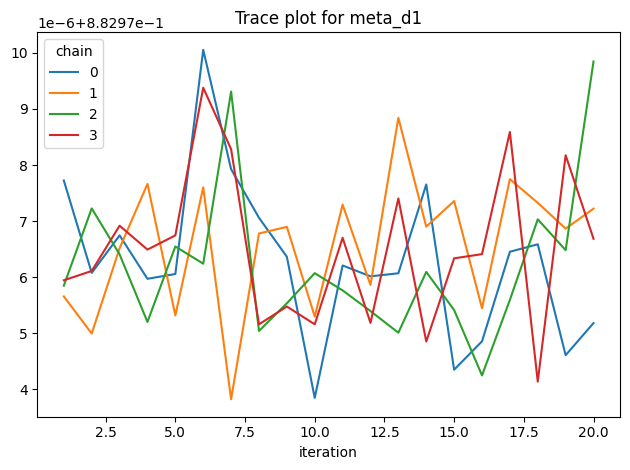

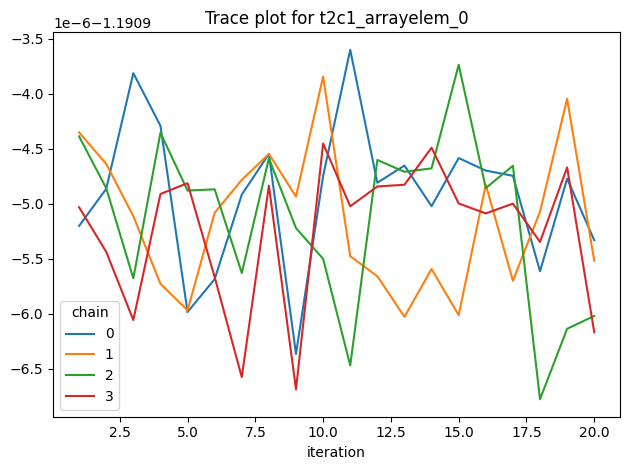

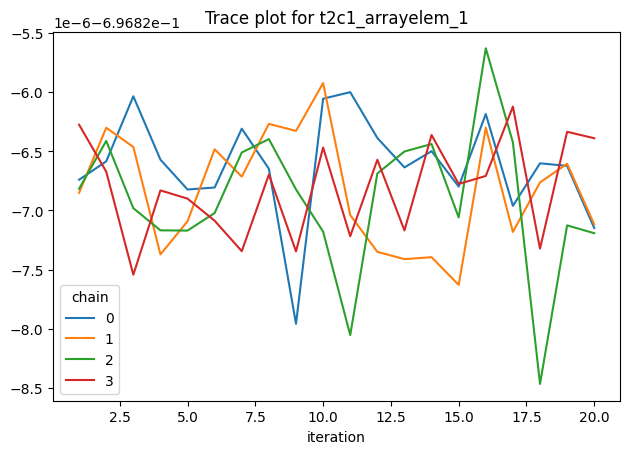

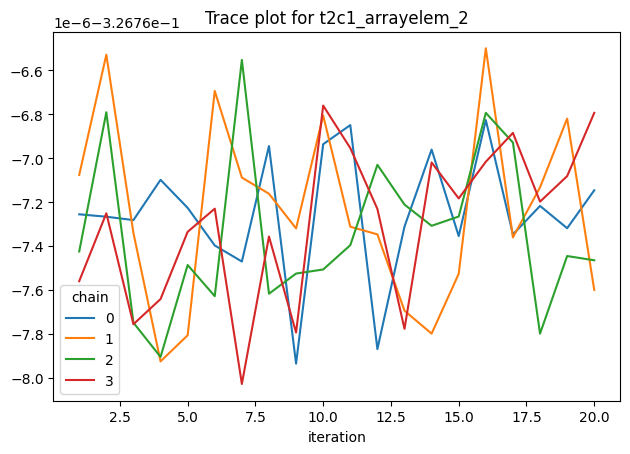

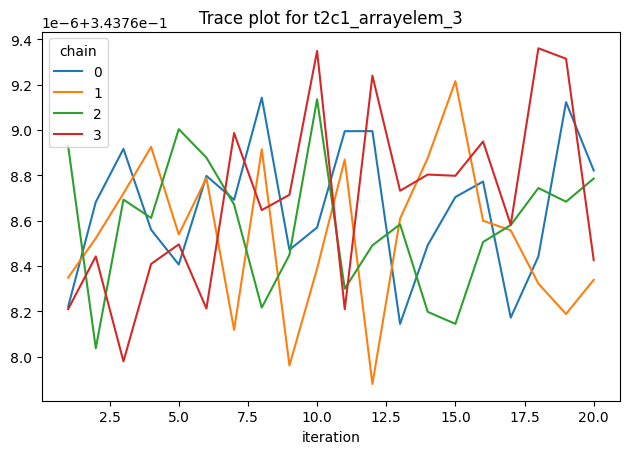

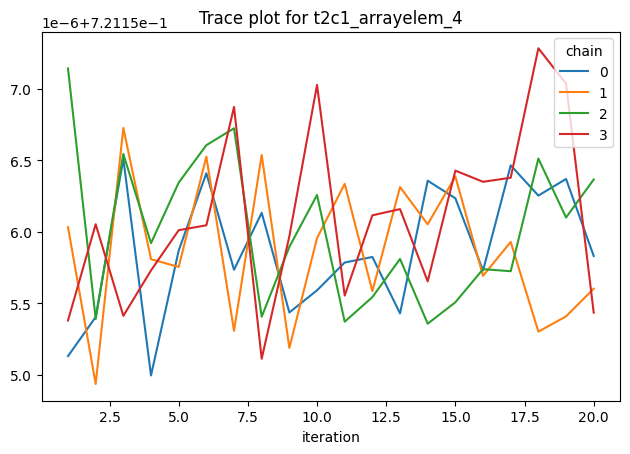

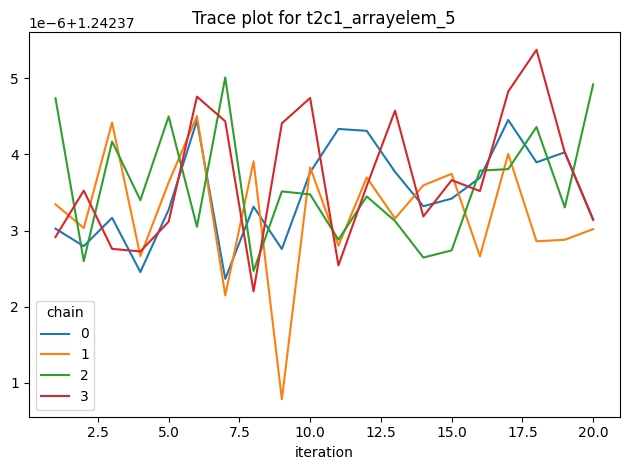

          parameter      mean    median           std  ci_lower  ci_upper
0           meta_d1  0.882976  0.882976  1.314229e-06  0.882974  0.882979
1  t2c1_arrayelem_0 -1.190905 -1.190905  6.865575e-07 -1.190907 -1.190904
2  t2c1_arrayelem_1 -0.696827 -0.696827  4.965627e-07 -0.696828 -0.696826
3  t2c1_arrayelem_2 -0.326767 -0.326767  3.566294e-07 -0.326768 -0.326767
4  t2c1_arrayelem_3  0.343769  0.343769  3.405029e-07  0.343768  0.343769
5  t2c1_arrayelem_4  0.721156  0.721156  5.250414e-07  0.721155  0.721157
6  t2c1_arrayelem_5  1.242374  1.242373  8.025652e-07  1.242372  1.242375


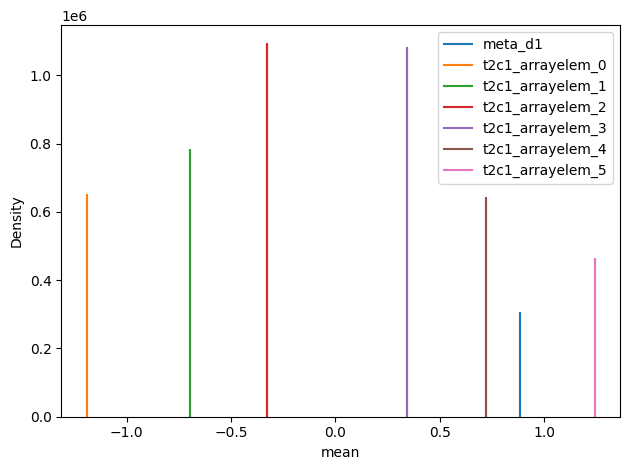

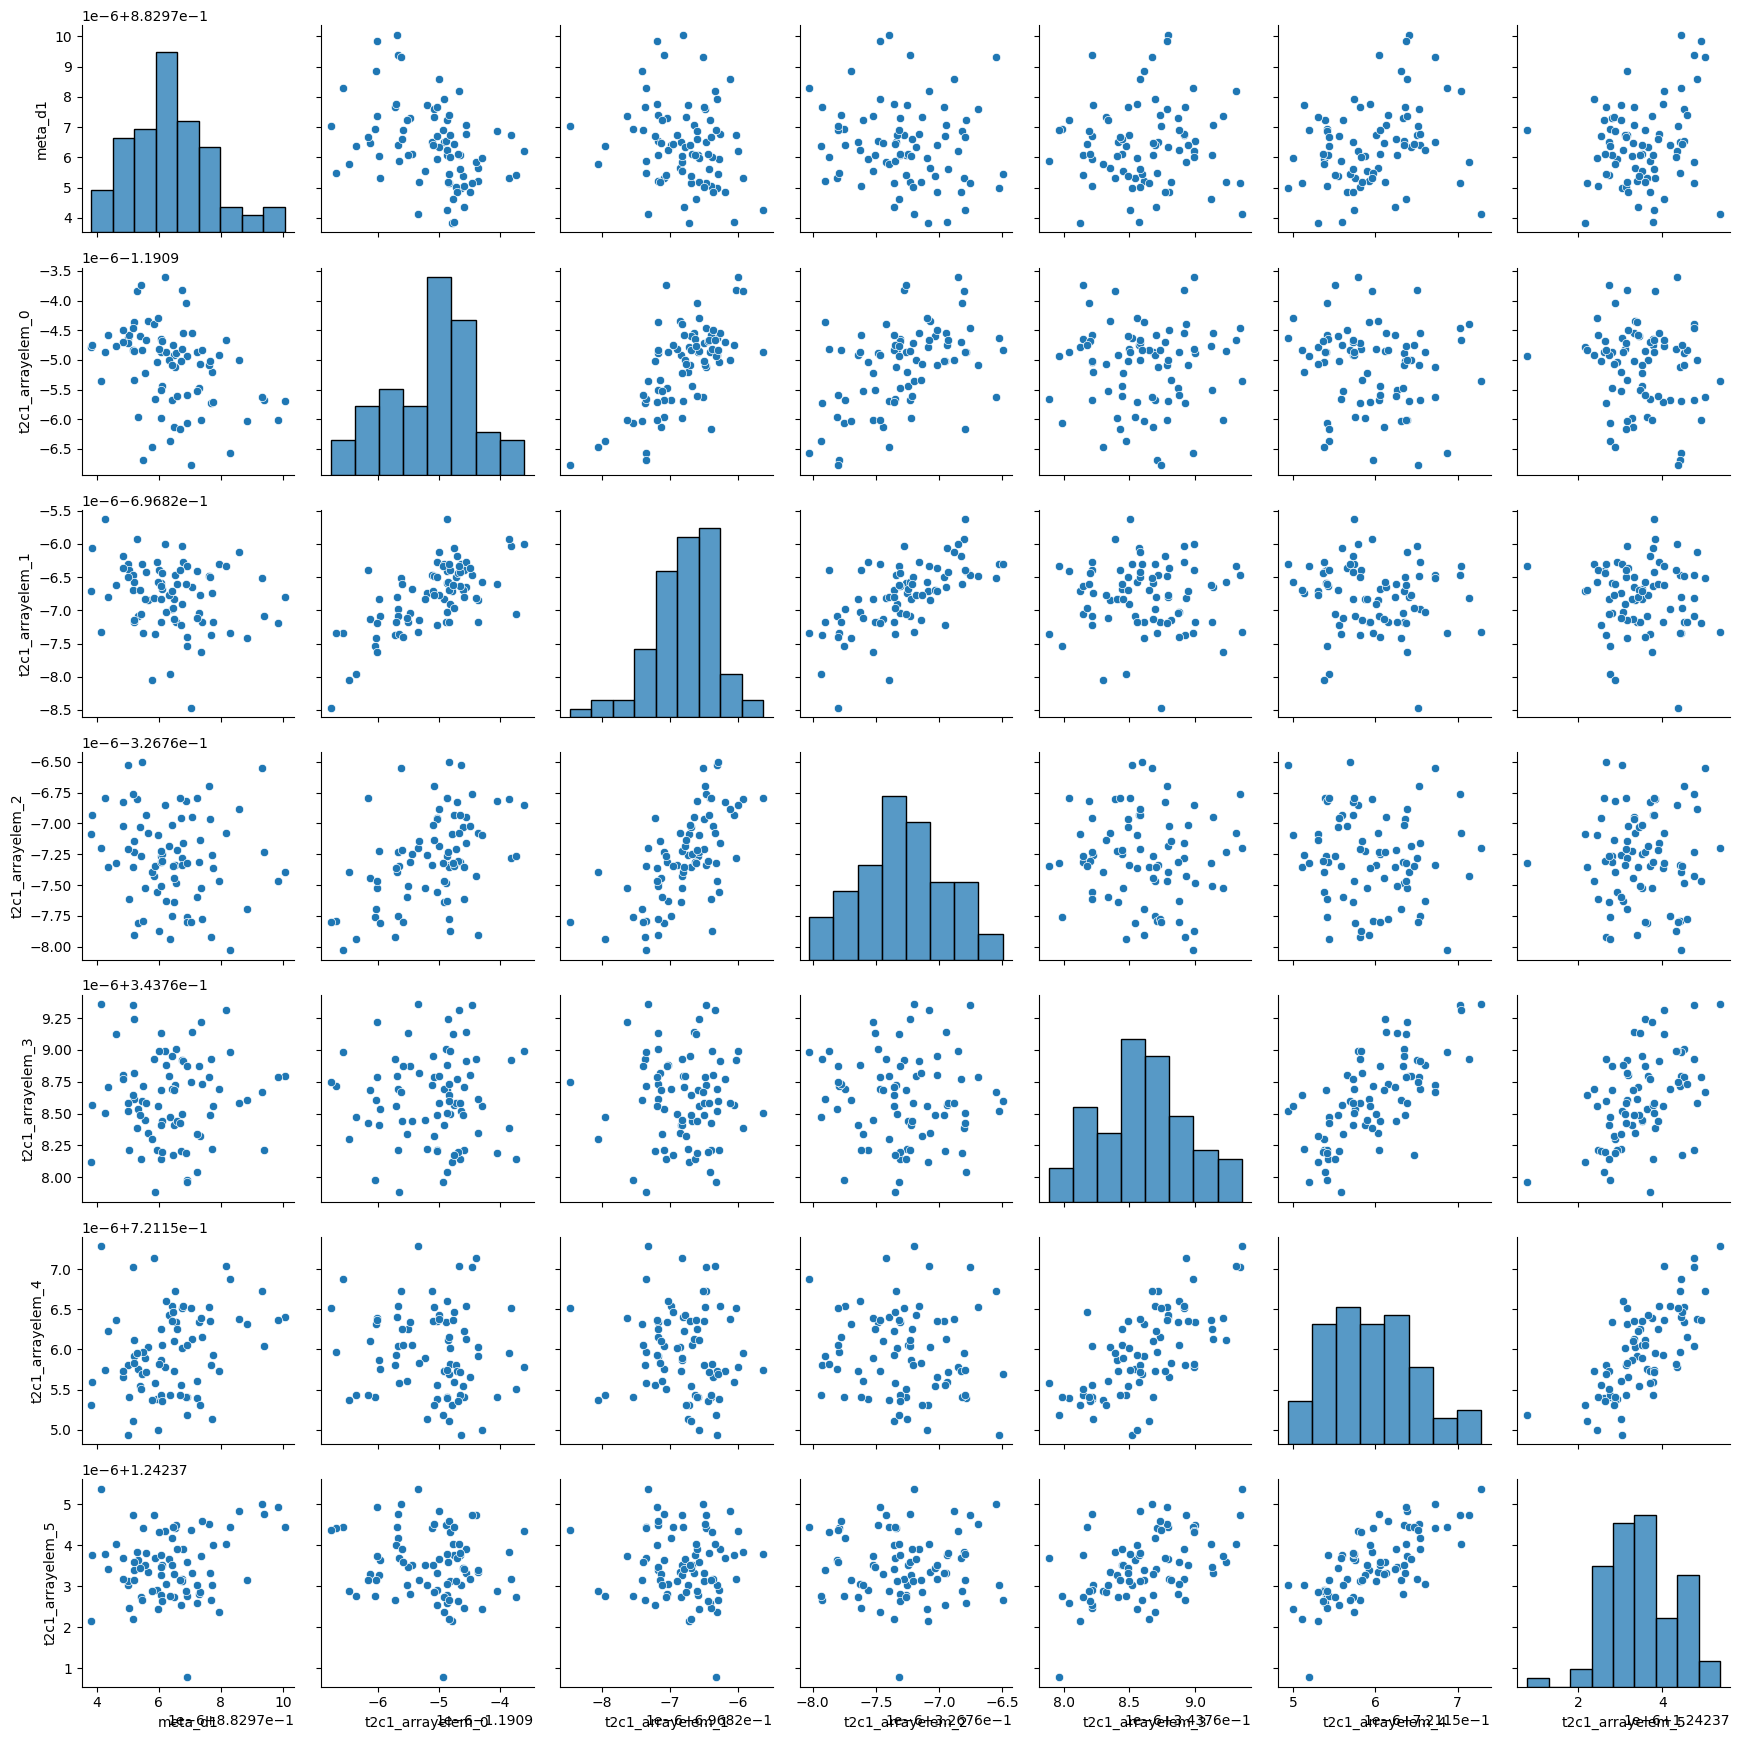

In [47]:
# Trace plots for each parameter
for param in df["parameter"].unique():
    param_data = df[df["parameter"] == param]
    param_data.pivot(index="iteration", columns="chain", values="mean").plot()
    plt.title(f"Trace plot for {param}")
    plt.tight_layout()
    plt.show()

# Burn-in and thinning
burn_in = 0
thinning = 1
filtered_df = df[(df["iteration"] > burn_in) & (df["iteration"] % thinning == 0)]

# Summary statistics for each parameter
summary = (
    filtered_df.groupby("parameter")["mean"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        ci_lower=lambda x: np.percentile(x, 2.5),
        ci_upper=lambda x: np.percentile(x, 97.5)
    )
    .reset_index()
)
print(summary)

# Visualize posterior distributions
for param in filtered_df["parameter"].unique():
    sns.kdeplot(filtered_df[filtered_df["parameter"] == param]["mean"], label=param)
plt.legend()
plt.tight_layout()
plt.show()

# Pair plot (if there are multiple parameters)
if filtered_df["parameter"].nunique() > 1:
    param_data = filtered_df.pivot(index=["iteration", "chain"], columns="parameter", values="mean").reset_index()
    sns.pairplot(param_data, vars=filtered_df["parameter"].unique())
    plt.tight_layout()
    plt.show()

In [34]:
# simulation = MetaSignalDetectionSimulator(
#     wrapper=wrapper, parameters=params, data=data.groupby('ppt'), solver="fminbound", parallel=True, ppt_identifier="ppt", num_trials=1000
# )
# simulation.run(verbose=False, num_starts=5, num_samples=10)
# simulation_results = simulation.export() # export the simulation results to a pandas DataFrame


In [35]:
# display(simulation_results)

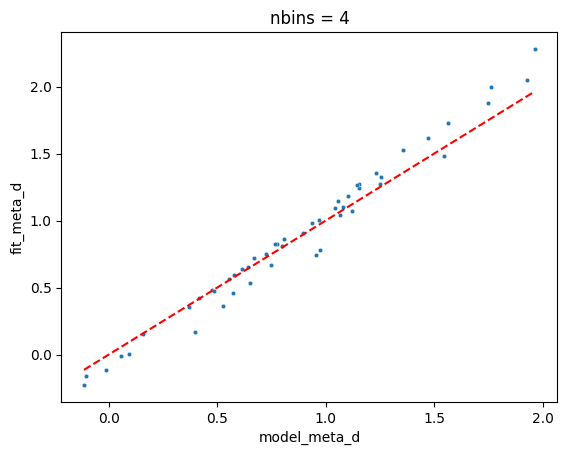

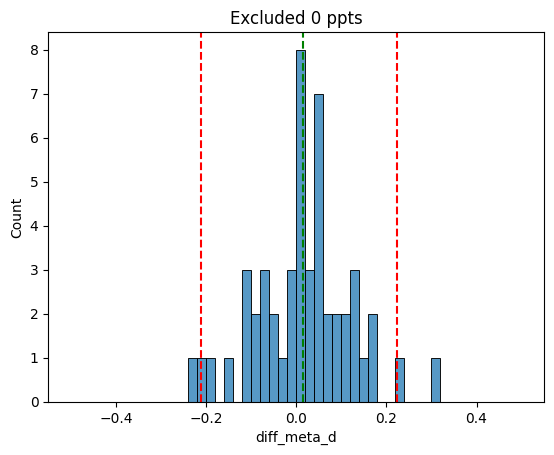

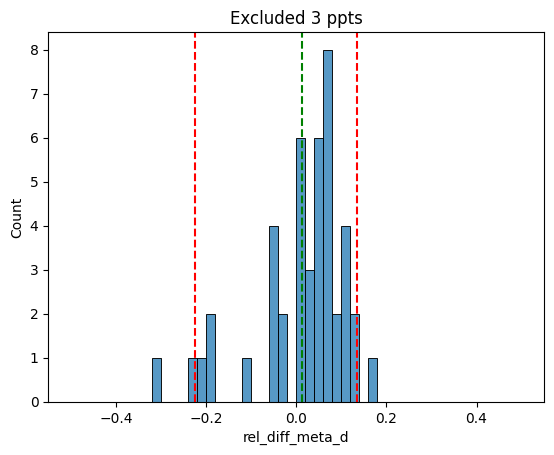

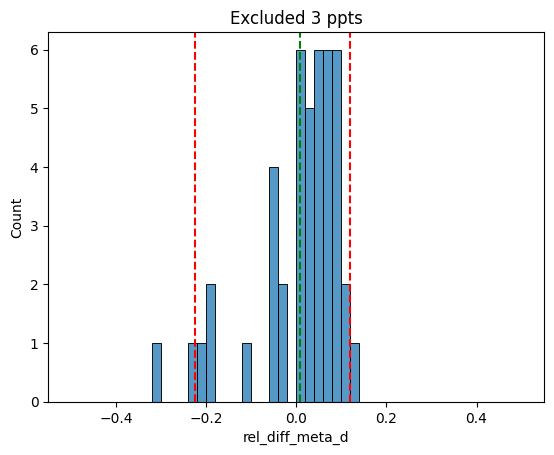

In [36]:
# plot model_meta_d vs fit_meta_d
for nb in nbins_list:
    binres = total_results[total_results['nbins'] == nb]
    plt.figure()
    plt.title(f'nbins = {nb}')
    sns.scatterplot(data=binres, x='model_meta_d', y='fit_meta_d', s=10)
    plt.xlabel('model_meta_d')
    plt.ylabel('fit_meta_d')
    minimu = np.maximum(binres['model_meta_d'].min(), binres['fit_meta_d'].min())
    maximu = np.minimum(binres['model_meta_d'].max(), binres['fit_meta_d'].max())
    plt.plot([minimu, maximu], [minimu, maximu], color='red', linestyle='--')
    plt.show()

# plot distribution of differences between model_meta_d and fit_meta_d
plt.figure()
sns.histplot(data=total_results, x='diff_meta_d', bins=50, binrange=(-0.5, 0.5))
plt.xlabel('diff_meta_d')
# plot quantiles
q1 = total_results['diff_meta_d'][total_results["diff_meta_d"] <= 0.5].quantile(0.025)
mean = total_results['diff_meta_d'][np.abs(total_results['diff_meta_d']) <= 0.5].mean()
q3 = total_results['diff_meta_d'][total_results["diff_meta_d"] <= 0.5].quantile(0.975)
plt.axvline(q1, color='red', linestyle='--')
plt.axvline(mean, color='green', linestyle='--')
plt.axvline(q3, color='red', linestyle='--')
plt.title(f'Excluded {len(total_results[total_results["diff_meta_d"] > 0.5])} ppts')
plt.show()

# plot distribution of relative differences between model_meta_d and fit_meta_d
plt.figure()
sns.histplot(data=total_results, x='rel_diff_meta_d', bins=50, binrange=(-0.5, 0.5))
plt.xlabel('rel_diff_meta_d')
# plot quantiles
q1 = total_results['rel_diff_meta_d'][np.abs(total_results['rel_diff_meta_d']) <= 0.5].quantile(0.025)
mean = total_results['rel_diff_meta_d'][np.abs(total_results['rel_diff_meta_d']) <= 0.5].mean()
q3 = total_results['rel_diff_meta_d'][np.abs(total_results['rel_diff_meta_d']) <= 0.5].quantile(0.975)
plt.axvline(q1, color='red', linestyle='--')
plt.axvline(mean, color='green', linestyle='--')
plt.axvline(q3, color='red', linestyle='--')
plt.title(f'Excluded {len(total_results[total_results["rel_diff_meta_d"] > 0.5])} ppts')
plt.show()

# new rel diff
x = total_results['diff_meta_d'] / np.maximum(total_results['model_meta_d'], total_results['fit_meta_d'])
plt.figure()
sns.histplot(x, bins=50, binrange=(-0.5, 0.5))
plt.xlabel('rel_diff_meta_d')
# plot quantiles
q1 = x[np.abs(x) <= 0.5].quantile(0.025)
mean = x[np.abs(x) <= 0.5].mean()
q3 = x[np.abs(x) <= 0.5].quantile(0.975)
plt.axvline(q1, color='red', linestyle='--')
plt.axvline(mean, color='green', linestyle='--')
plt.axvline(q3, color='red', linestyle='--')
plt.title(f'Excluded {len(total_results[x > 0.5])} ppts')
plt.show()

In [37]:
# showcols = ['ppt', 'nbins', 'diff_d1', 'rel_diff_d1', 'diff_meta_d', 'rel_diff_meta_d', 'diff_M_ratio', 'rel_diff_M_ratio']
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
#     # display(total_results[showcols].sort_values(by=['nbins']))
#     pass

# comparison = comparison.sort_values(by=['user_id'])
# total_results = total_results.sort_values(by=['subject'])


# # extract number of trials in data
# data = data.sort_values(by=['subject'])
# num_trials = []
# for s in data['subject'].unique():
#     num_trials.append(data[data['subject'] == s].shape[0])

# # plot meta_d standard deviation vs diff_meta_d
# fig, axs = plt.subplots(1, 2, figsize=(20,6))
# axs[0].plot(simulation_results[('meta_d1', 'std')], total_results['diff_meta_d'].abs(), 'o')
# axs[1].plot(simulation_results[('meta_d1', 'std')], total_results['rel_diff_meta_d'].abs(), 'o')
# axs[0].set_xlabel('meta_d std')
# axs[1].set_xlabel('meta_d std')
# axs[0].set_ylabel('diff_meta_d')
# axs[1].set_ylabel('rel_diff_meta_d')
# plt.show()

# # plot meta_d from simulation vs fit
# plt.figure()
# plt.plot(total_results['fit_meta_d'], simulation_results[('meta_d1', 'mean')], 'o')
# xlim = plt.gca().get_xlim()
# ylim = plt.gca().get_ylim()
# plt.plot([-100, 100], [-100, 100], 'k--')
# plt.xlim(xlim)
# plt.ylim(ylim)
# plt.xlabel('fit_meta_d')
# plt.ylabel('sim_meta_d')
# plt.show()

# # plot
# plt.figure()
# plt.plot(simulation_results[('meta_d1', 'std')], np.abs(total_results['fit_meta_d'] - simulation_results[('meta_d1','mean')]), 'o')
# xlim = plt.gca().get_xlim()
# ylim = plt.gca().get_ylim()
# plt.xlim(xlim)
# plt.ylim(ylim)
# plt.show()



In [38]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
from cpm.models.signal_detection import MetaSignalDetectionHelper
# import Union
from typing import Union, Tuple, Dict

"""
[translated by alan lee from trials2counts.m by Maniscalco & Lau (2012)]
[requires numpy-1.16.4, scipy-1.3.0, or later versions]
[comments below are copied and pasted from trials2counts.m]

function [nR_S1, nR_S2] = trials2counts(stimID, response, rating, nRatings, padCells, padAmount)

% Given data from an experiment where an observer discriminates between two
% stimulus alternatives on every trial and provides confidence ratings,
% converts trial by trial experimental information for N trials into response 
% counts.
%
% INPUTS
% stimID:   1xN vector. stimID(i) = 0 --> stimulus on i'th trial was S1.
%                       stimID(i) = 1 --> stimulus on i'th trial was S2.
%
% response: 1xN vector. response(i) = 0 --> response on i'th trial was "S1".
%                       response(i) = 1 --> response on i'th trial was "S2".
%
% rating:   1xN vector. rating(i) = X --> rating on i'th trial was X.
%                       X must be in the range 1 <= X <= nRatings.
%
% N.B. all trials where stimID is not 0 or 1, response is not 0 or 1, or
% rating is not in the range [1, nRatings], are omitted from the response
% count.
%
% nRatings: total # of available subjective ratings available for the
%           subject. e.g. if subject can rate confidence on a scale of 1-4,
%           then nRatings = 4
%
% optional inputs
%
% padCells: if set to 1, each response count in the output has the value of
%           padAmount added to it. Padding cells is desirable if trial counts 
%           of 0 interfere with model fitting.
%           if set to 0, trial counts are not manipulated and 0s may be
%           present in the response count output.
%           default value for padCells is 0.
%
% padAmount: the value to add to each response count if padCells is set to 1.
%            default value is 1/(2*nRatings)
%
%
% OUTPUTS
% nR_S1, nR_S2
% these are vectors containing the total number of responses in
% each response category, conditional on presentation of S1 and S2.
%
% e.g. if nR_S1 = [100 50 20 10 5 1], then when stimulus S1 was
% presented, the subject had the following response counts:
% responded S1, rating=3 : 100 times
% responded S1, rating=2 : 50 times
% responded S1, rating=1 : 20 times
% responded S2, rating=1 : 10 times
% responded S2, rating=2 : 5 times
% responded S2, rating=3 : 1 time
%
% The ordering of response / rating counts for S2 should be the same as it
% is for S1. e.g. if nR_S2 = [3 7 8 12 27 89], then when stimulus S2 was
% presented, the subject had the following response counts:
% responded S1, rating=3 : 3 times
% responded S1, rating=2 : 7 times
% responded S1, rating=1 : 8 times
% responded S2, rating=1 : 12 times
% responded S2, rating=2 : 27 times
% responded S2, rating=3 : 89 times
"""

def trials2counts(stimID, response, rating, nRatings, padCells = 0, padAmount = None):

    ''' sort inputs '''
    # check for valid inputs
    if not ( len(stimID) == len(response)) and (len(stimID) == len(rating)):
        raise('stimID, response, and rating input vectors must have the same lengths')
    
    ''' filter bad trials '''
    tempstim = []
    tempresp = []
    tempratg = []
    for s,rp,rt in zip(stimID,response,rating):
        if (s == 0 or s == 1) and (rp == 0 or rp == 1) and (rt >=1 and rt <= nRatings):
            tempstim.append(s)
            tempresp.append(rp)
            tempratg.append(rt)
    stimID = tempstim
    response = tempresp
    rating = tempratg
    
    ''' set input defaults '''
    if padAmount == None:
        padAmount = 1/(2*nRatings)
    
    ''' compute response counts '''
    nR_S1 = []
    nR_S2 = []

    # S1 responses
    for r in range(nRatings,0,-1):
        cs1, cs2 = 0,0
        for s,rp,rt in zip(stimID, response, rating):
            if s==0 and rp==0 and rt==r:
                cs1 += 1
            if s==1 and rp==0 and rt==r:
                cs2 += 1
        nR_S1.append(cs1)
        nR_S2.append(cs2)
    
    # S2 responses
    for r in range(1,nRatings+1,1):
        cs1, cs2 = 0,0
        for s,rp,rt in zip(stimID, response, rating):
            if s==0 and rp==1 and rt==r:
                cs1 += 1
            if s==1 and rp==1 and rt==r:
                cs2 += 1
        nR_S1.append(cs1)
        nR_S2.append(cs2)
    
    # pad response counts to avoid zeros
    if padCells:
        nR_S1 = [n+padAmount for n in nR_S1]
        nR_S2 = [n+padAmount for n in nR_S2]
        
    return nR_S1, nR_S2


def discreteRatings(
    ratings: Union[list, np.ndarray],
    nbins: int = 4,
    verbose: bool = True,
    ignore_invalid: bool = False,
) -> Tuple[np.ndarray, Dict[str, list]]:
    """Convert from continuous to discrete ratings.

    Resample if quantiles are equal at high or low end to ensure proper
    assignment of binned confidence

    Parameters
    ----------
    ratings : list | np.ndarray
        Ratings on a continuous scale.
    nbins : int
        The number of discrete ratings to resample. Defaut set to `4`.
    verbose : boolean
        If `True`, warning warnings be returned.
    ignore_invalid : bool
        If `False` (default), an arreor will be raised in case of impossible
        discretisation of the confidence ratings. This is mostly due to identical
        values and SDT values should not be extracted from the data. If `True` the
        discretisation will process anyway. This option can be usefull for plotting.

    Returns
    -------
    discreteRatings : np.ndarray
        New rating array only containing integers between 1 and `nbins`.
    out : dict
        Dictionary containing logs of the discrization process:
            * `'confbins'`: list or 1d array-like - If the ratings were
                reampled, a list containing the new ratings and the new low or
                hg threshold, appened before or after the rating, respectively.
                Else, only returns the ratings.
            * `'rebin'`: boolean - If True, the ratings were resampled due to
                larger numbers of highs or low ratings.
            * `'binCount'` : int - Number of bins

    .. warning:: This function will automatically control for bias in high or
        low confidence ratings. If the first two or the last two quantiles
        have identical values, low or high confidence trials are excluded
        (respectively), and the function is run again on the remaining data.

    Raises
    ------
    ValueError:
        If the confidence ratings contains a lot of identical values and
        `ignore_invalid` is `False`.

    Examples
    --------
    >>> from metadpy.utils import discreteRatings
    >>> ratings = np.array([
    >>>     96, 98, 95, 90, 32, 58, 77,  6, 78, 78, 62, 60, 38, 12,
    >>>     63, 18, 15, 13, 49, 26,  2, 38, 60, 23, 25, 39, 22, 33,
    >>>     32, 27, 40, 13, 35, 16, 35, 73, 50,  3, 40, 0, 34, 47,
    >>>     52,  0,  0,  0, 25,  1, 16, 37, 59, 20, 25, 23, 45, 22,
    >>>     28, 62, 61, 69, 20, 75, 10, 18, 61, 27, 63, 22, 54, 30,
    >>>     36, 66, 14,  2, 53, 58, 88, 23, 77, 54])
    >>> discreteRatings, out = discreteRatings(ratings)
    (array([4, 4, 4, 4, 2, 3, 4, 1, 4, 4, 4, 4, 3, 1, 4, 1, 1, 1, 3, 2, 1, 3,
        4, 2, 2, 3, 2, 2, 2, 2, 3, 1, 3, 1, 3, 4, 3, 1, 3, 1, 2, 3, 3, 1,
        1, 1, 2, 1, 1, 3, 3, 2, 2, 2, 3, 2, 2, 4, 4, 4, 2, 4, 1, 1, 4, 2,
        4, 2, 3, 2, 3, 4, 1, 1, 3, 3, 4, 2, 4, 3]),
    {'confBins': array([ 0., 20., 35., 60., 98.]), 'rebin': 0, 'binCount': 21})

    """
    out, temp = {}, []
    confBins = np.quantile(ratings, np.linspace(0, 1, nbins + 1))
    if (confBins[0] == confBins[1]) & (confBins[nbins - 1] == confBins[nbins]):
        if ignore_invalid is False:
            raise ValueError(
                "The resulting rating scale contains a lot of identical"
                " values and cannot be further analyzed"
            )
    elif confBins[nbins - 1] == confBins[nbins]:
        # Exclude high confidence trials and re-estimate
        hiConf = confBins[-1]
        confBins = np.quantile(ratings[ratings != hiConf], np.linspace(0, 1, nbins))
        for b in range(len(confBins) - 1):
            temp.append((ratings >= confBins[b]) & (ratings <= confBins[b + 1]))
        temp.append(ratings == hiConf)

        out["confBins"] = [confBins, hiConf]
        out["rebin"] = [1]
    elif confBins[0] == confBins[1]:
        # Exclude low confidence trials and re-estimate
        lowConf = confBins[1]
        temp.append(ratings == lowConf)
        confBins = np.quantile(ratings[ratings != lowConf], np.linspace(0, 1, nbins))
        for b in range(1, len(confBins)):
            temp.append((ratings >= confBins[b - 1]) & (ratings <= confBins[b]))
        out["confBins"] = [lowConf, confBins]
        out["rebin"] = [1]
    else:
        for b in range(len(confBins) - 1):
            temp.append((ratings >= confBins[b]) & (ratings <= confBins[b + 1]))
        out["confBins"] = confBins
        out["rebin"] = [0]

    discreteRatings = np.zeros(len(ratings), dtype="int")
    for b in range(nbins):
        discreteRatings[temp[b]] = b
    discreteRatings += 1
    out["binCount"] = [sum(temp[b])]

    return discreteRatings, out

n = 10000
stimID =    np.random.randint(0,2,n)
response =  np.random.randint(0,2,n)
rating =    np.random.uniform(0,1,n)
rating__ = discreteRatings(rating, nbins=4)[0]

nRatings = 4

nR_S1, nR_S2 = trials2counts(stimID, response, rating__, nRatings, 1)
print(np.array(nR_S1).astype(int))
print(np.array(nR_S2).astype(int))
print(np.sum(nR_S1)+np.sum(nR_S2)-2)


IndentationError: expected an indented block after 'if' statement on line 213 (1780744324.py, line 215)

In [93]:
# import pandas as pd
# import sys
# sys.path.append('../..')
# from cpm.models.signal_detection import MetaSignalDetectionHelper

# data = pd.DataFrame({
#     'ppt': [1]*n,
#     'stimulus': stimID,
#     'response': response,
#     'confidence': rating/100,
# })

# msdh = MetaSignalDetectionHelper(data, nbins=4, apply_adjustment=True)
# print(msdh.nR_S1.astype(int))
# print(msdh.nR_S2.astype(int))
# print(np.sum(msdh.nR_S1)+np.sum(msdh.nR_S2)-2)

In [94]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Jul 12 14:13:24 2019

[translated from fit_meta_d_MLE.m by Maniscalco & Lau (2012) by alan lee]
[requires numpy-1.13.3, scipy-1.1.0, or later versions]
[comments below are copied and pasted from fit_meta_d_MLE.m]

function fit = fit_meta_d_MLE(nR_S1, nR_S2, s, fncdf, fninv)

% fit = fit_meta_d_MLE(nR_S1, nR_S2, s, fncdf, fninv)
%
% Given data from an experiment where an observer discriminates between two
% stimulus alternatives on every trial and provides confidence ratings,
% provides a type 2 SDT analysis of the data.
%
% INPUTS
%
% * nR_S1, nR_S2
% these are vectors containing the total number of responses in
% each response category, conditional on presentation of S1 and S2.
%
% e.g. if nR_S1 = [100 50 20 10 5 1], then when stimulus S1 was
% presented, the subject had the following response counts:
% responded S1, rating=3 : 100 times
% responded S1, rating=2 : 50 times
% responded S1, rating=1 : 20 times
% responded S2, rating=1 : 10 times
% responded S2, rating=2 : 5 times
% responded S2, rating=3 : 1 time
%
% The ordering of response / rating counts for S2 should be the same as it
% is for S1. e.g. if nR_S2 = [3 7 8 12 27 89], then when stimulus S2 was
% presented, the subject had the following response counts:
% responded S1, rating=3 : 3 times
% responded S1, rating=2 : 7 times
% responded S1, rating=1 : 8 times
% responded S2, rating=1 : 12 times
% responded S2, rating=2 : 27 times
% responded S2, rating=3 : 89 times
%
% N.B. if nR_S1 or nR_S2 contain zeros, this may interfere with estimation of
% meta-d'.
%
% Some options for dealing with response cell counts containing zeros are:
% 
% (1) Add a small adjustment factor, e.g. adj_f = 1/(length(nR_S1), to each 
% input vector:
% 
% adj_f = 1/length(nR_S1);
% nR_S1_adj = nR_S1 + adj_f;
% nR_S2_adj = nR_S2 + adj_f;
% 
% This is a generalization of the correction for similar estimation issues of
% type 1 d' as recommended in
% 
% Hautus, M. J. (1995). Corrections for extreme proportions and their biasing 
%     effects on estimated values of d'. Behavior Research Methods, Instruments, 
%     & Computers, 27, 46-51.
%     
% When using this correction method, it is recommended to add the adjustment 
% factor to ALL data for all subjects, even for those subjects whose data is 
% not in need of such correction, in order to avoid biases in the analysis 
% (cf Snodgrass & Corwin, 1988).
% 
% (2) Collapse across rating categories.
% 
% e.g. if your data set has 4 possible confidence ratings such that length(nR_S1)==8,
% defining new input vectors
% 
% nR_S1_new = [sum(nR_S1(1:2)), sum(nR_S1(3:4)), sum(nR_S1(5:6)), sum(nR_S1(7:8))];
% nR_S2_new = [sum(nR_S2(1:2)), sum(nR_S2(3:4)), sum(nR_S2(5:6)), sum(nR_S2(7:8))];
% 
% might be sufficient to eliminate zeros from the input without using an adjustment.
%
% * s
% this is the ratio of standard deviations for type 1 distributions, i.e.
%
% s = sd(S1) / sd(S2)
%
% if not specified, s is set to a default value of 1.
% For most purposes, we recommend setting s = 1. 
% See http://www.columbia.edu/~bsm2105/type2sdt for further discussion.
%
% * fncdf
% a function handle for the CDF of the type 1 distribution.
% if not specified, fncdf defaults to @normcdf (i.e. CDF for normal
% distribution)
%
% * fninv
% a function handle for the inverse CDF of the type 1 distribution.
% if not specified, fninv defaults to @norminv
%
% OUTPUT
%
% Output is packaged in the struct "fit." 
% In the following, let S1 and S2 represent the distributions of evidence 
% generated by stimulus classes S1 and S2.
% Then the fields of "fit" are as follows:
% 
% fit.da        = mean(S2) - mean(S1), in room-mean-square(sd(S1),sd(S2)) units
% fit.s         = sd(S1) / sd(S2)
% fit.meta_da   = meta-d' in RMS units
% fit.M_diff    = meta_da - da
% fit.M_ratio   = meta_da / da
% fit.meta_ca   = type 1 criterion for meta-d' fit, RMS units
% fit.t2ca_rS1  = type 2 criteria of "S1" responses for meta-d' fit, RMS units
% fit.t2ca_rS2  = type 2 criteria of "S2" responses for meta-d' fit, RMS units
%
% fit.S1units   = contains same parameters in sd(S1) units.
%                 these may be of use since the data-fitting is conducted  
%                 using parameters specified in sd(S1) units.
% 
% fit.logL          = log likelihood of the data fit
%
% fit.est_HR2_rS1  = estimated (from meta-d' fit) type 2 hit rates for S1 responses
% fit.obs_HR2_rS1  = actual type 2 hit rates for S1 responses
% fit.est_FAR2_rS1 = estimated type 2 false alarm rates for S1 responses
% fit.obs_FAR2_rS1 = actual type 2 false alarm rates for S1 responses
% 
% fit.est_HR2_rS2  = estimated type 2 hit rates for S2 responses
% fit.obs_HR2_rS2  = actual type 2 hit rates for S2 responses
% fit.est_FAR2_rS2 = estimated type 2 false alarm rates for S2 responses
% fit.obs_FAR2_rS2 = actual type 2 false alarm rates for S2 responses
%
% If there are N ratings, then there will be N-1 type 2 hit rates and false
% alarm rates. 

% 2019/07/12 - translated to python3 by alan lee
                [requires numpy-1.13.3, scipy-1.1.0, or later versions]
% 2015/07/23 - fixed bug for output fit.meta_ca and fit.S1units.meta_c1. 
%            - added comments to help section as well as a warning output 
%              for nR_S1 or nR_S2 inputs containing zeros
% 2014/10/14 - updated discussion of "s" input in the help section above.
% 2010/09/07 - created
"""

import numpy as np
from scipy.stats import norm
from scipy.optimize import Bounds, LinearConstraint, minimize, SR1

# returns negative log-likelihood of parameters given experimental data
# parameters[0] = meta d'
# parameters[1:end] = type-2 criteria locations
def fit_meta_d_logL(parameters,inputObj):
    meta_d1 = parameters[0]
    t2c1    = parameters[1:]
    nR_S1, nR_S2, nRatings, d1, t1c1, s, constant_criterion, fncdf, fninv = inputObj

    # define mean and SD of S1 and S2 distributions
    S1mu = -meta_d1/2
    S1sd = 1
    S2mu = meta_d1/2
    S2sd = S1sd/s

    # adjust so that the type 1 criterion is set at 0
    # (this is just to work with optimization toolbox constraints...
    #  to simplify defining the upper and lower bounds of type 2 criteria)
    S1mu = S1mu - eval(constant_criterion)
    S2mu = S2mu - eval(constant_criterion)

    t1c1 = 0

    # set up MLE analysis
    # get type 2 response counts
    # S1 responses
    nC_rS1 = [nR_S1[i] for i in range(nRatings)]
    nI_rS1 = [nR_S2[i] for i in range(nRatings)]
    # S2 responses
    nC_rS2 = [nR_S2[i+nRatings] for i in range(nRatings)]
    nI_rS2 = [nR_S1[i+nRatings] for i in range(nRatings)]

    # get type 2 probabilities
    C_area_rS1 = fncdf(t1c1,S1mu,S1sd)
    I_area_rS1 = fncdf(t1c1,S2mu,S2sd)
    
    C_area_rS2 = 1-fncdf(t1c1,S2mu,S2sd)
    I_area_rS2 = 1-fncdf(t1c1,S1mu,S1sd)
    
    t2c1x = [-np.inf]
    t2c1x.extend(t2c1[0:(nRatings-1)])
    t2c1x.append(t1c1)
    t2c1x.extend(t2c1[(nRatings-1):])
    t2c1x.append(np.inf)

    prC_rS1 = [( fncdf(t2c1x[i+1],S1mu,S1sd) - fncdf(t2c1x[i],S1mu,S1sd) ) / C_area_rS1 for i in range(nRatings)]
    prI_rS1 = [( fncdf(t2c1x[i+1],S2mu,S2sd) - fncdf(t2c1x[i],S2mu,S2sd) ) / I_area_rS1 for i in range(nRatings)]

    prC_rS2 = [( (1-fncdf(t2c1x[nRatings+i],S2mu,S2sd)) - (1-fncdf(t2c1x[nRatings+i+1],S2mu,S2sd)) ) / C_area_rS2 for i in range(nRatings)]
    prI_rS2 = [( (1-fncdf(t2c1x[nRatings+i],S1mu,S1sd)) - (1-fncdf(t2c1x[nRatings+i+1],S1mu,S1sd)) ) / I_area_rS2 for i in range(nRatings)]

    # calculate logL
    logL = np.sum([
            nC_rS1[i]*np.log(prC_rS1[i]) \
            + nI_rS1[i]*np.log(prI_rS1[i]) \
            + nC_rS2[i]*np.log(prC_rS2[i]) \
            + nI_rS2[i]*np.log(prI_rS2[i]) for i in range(nRatings)])
    
    if np.isinf(logL) or np.isnan(logL):
#        logL=-np.inf
        logL=-1e+300 # returning "-inf" may cause optimize.minimize() to fail
    return -logL


def fit_meta_d_MLE(nR_S1, nR_S2, s = 1, fncdf = norm.cdf, fninv = norm.ppf):

    # check inputs
    if (len(nR_S1) % 2)!=0: 
        raise('input arrays must have an even number of elements')
    if len(nR_S1)!=len(nR_S2):
        raise('input arrays must have the same number of elements')
    if any(np.array(nR_S1) == 0) or any(np.array(nR_S2) == 0):
        print(' ')
        print('WARNING!!')
        print('---------')
        print('Your inputs')
        print(' ')
        print('nR_S1:')
        print(nR_S1)
        print('nR_S2:')
        print(nR_S2)
        print(' ')
        print('contain zeros! This may interfere with proper estimation of meta-d''.')
        print('See ''help fit_meta_d_MLE'' for more information.')
        print(' ')
        print(' ')
    
    nRatings = int(len(nR_S1) / 2)  # number of ratings in the experiment
    nCriteria = int(2*nRatings - 1) # number criteria to be fitted
    
    """
    set up constraints for scipy.optimize.minimum()
    """
    # parameters
    # meta-d' - 1
    # t2c     - nCriteria-1
    # constrain type 2 criteria values,
    # such that t2c(i) is always <= t2c(i+1)
    # want t2c(i)   <= t2c(i+1) 
    # -->  t2c(i+1) >= t2c(i) + 1e-5 (i.e. very small deviation from equality) 
    # -->  t2c(i) - t2c(i+1) <= -1e-5 
    A = []
    ub = []
    lb = []
    for ii in range(nCriteria-2):
        tempArow = []
        tempArow.extend(np.zeros(ii+1))
        tempArow.extend([1, -1])
        tempArow.extend(np.zeros((nCriteria-2)-ii-1))
        A.append(tempArow)
        ub.append(-1e-5)
        lb.append(-np.inf)
        
    # lower bounds on parameters
    LB = []
    LB.append(-10.)                              # meta-d'
    LB.extend(-20*np.ones((nCriteria-1)//2))    # criteria lower than t1c
    LB.extend(np.zeros((nCriteria-1)//2))       # criteria higher than t1c
    
    # upper bounds on parameters
    UB = []
    UB.append(10.)                           # meta-d'
    UB.extend(np.zeros((nCriteria-1)//2))      # criteria lower than t1c
    UB.extend(20*np.ones((nCriteria-1)//2))    # criteria higher than t1c
    
    """
    prepare other inputs for scipy.optimize.minimum()
    """
    # select constant criterion type
    constant_criterion = 'meta_d1 * (t1c1 / d1)' # relative criterion
    
    # set up initial guess at parameter values
    ratingHR  = []
    ratingFAR = []
    for c in range(1,int(nRatings*2)):
        ratingHR.append(sum(nR_S2[c:]) / sum(nR_S2))
        ratingFAR.append(sum(nR_S1[c:]) / sum(nR_S1))
    
    # obtain index in the criteria array to mark Type I and Type II criteria
    t1_index = nRatings-1
    t2_index = list(set(list(range(0,2*nRatings-1))) - set([t1_index]))
    
    d1 = (1/s) * fninv( ratingHR[t1_index] ) - fninv( ratingFAR[t1_index] )
    meta_d1 = d1
    
    c1 = (-1/(1+s)) * ( fninv( ratingHR ) + fninv( ratingFAR ) )
    t1c1 = c1[t1_index]
    t2c1 = c1[t2_index]
    
    # initial values for the minimization function
    guess = [meta_d1]
    guess.extend(list(t2c1 - eval(constant_criterion)))
    
    # other inputs for the minimization function
    inputObj = [nR_S1, nR_S2, nRatings, d1, t1c1, s, constant_criterion, fncdf, fninv]        
    bounds = Bounds(LB,UB)
    linear_constraint = LinearConstraint(A,lb,ub)
    
    # minimization of negative log-likelihood
    results = minimize(fit_meta_d_logL, guess, args = (inputObj), method='trust-constr',
                       jac='2-point', hess=SR1(),
                       constraints = [linear_constraint],
                       options = {'verbose': 0}, bounds = bounds)
    
    # quickly process some of the output
    meta_d1 = results.x[0]
    t2c1    = results.x[1:] + eval(constant_criterion)
    logL    = -results.fun
    
    # data is fit, now to package it...
    # find observed t2FAR and t2HR 
    
    # I_nR and C_nR are rating trial counts for incorrect and correct trials
    # element i corresponds to # (in)correct w/ rating i
    I_nR_rS2 = nR_S1[nRatings:]
    I_nR_rS1 = list(np.flip(nR_S2[0:nRatings],axis=0))
    
    C_nR_rS2 = nR_S2[nRatings:];
    C_nR_rS1 = list(np.flip(nR_S1[0:nRatings],axis=0))
    
    obs_FAR2_rS2 = [sum( I_nR_rS2[(i+1):] ) / sum(I_nR_rS2) for i in range(nRatings-1)]
    obs_HR2_rS2 = [sum( C_nR_rS2[(i+1):] ) / sum(C_nR_rS2) for i in range(nRatings-1)]
    obs_FAR2_rS1 = [sum( I_nR_rS1[(i+1):] ) / sum(I_nR_rS1) for i in range(nRatings-1)]
    obs_HR2_rS1 = [sum( C_nR_rS1[(i+1):] ) / sum(C_nR_rS1) for i in range(nRatings-1)]
    
    # find estimated t2FAR and t2HR
    S1mu = -meta_d1/2
    S1sd = 1
    S2mu =  meta_d1/2
    S2sd = S1sd/s
    
    mt1c1 = eval(constant_criterion)
    
    C_area_rS2 = 1-fncdf(mt1c1,S2mu,S2sd)
    I_area_rS2 = 1-fncdf(mt1c1,S1mu,S1sd)
    
    C_area_rS1 = fncdf(mt1c1,S1mu,S1sd)
    I_area_rS1 = fncdf(mt1c1,S2mu,S2sd)
    
    est_FAR2_rS2 = []
    est_HR2_rS2 = []
    
    est_FAR2_rS1 = []
    est_HR2_rS1 = []
    
    
    for i in range(nRatings-1):
        
        t2c1_lower = t2c1[(nRatings-1)-(i+1)]
        t2c1_upper = t2c1[(nRatings-1)+i]
            
        I_FAR_area_rS2 = 1-fncdf(t2c1_upper,S1mu,S1sd)
        C_HR_area_rS2  = 1-fncdf(t2c1_upper,S2mu,S2sd)
    
        I_FAR_area_rS1 = fncdf(t2c1_lower,S2mu,S2sd)
        C_HR_area_rS1  = fncdf(t2c1_lower,S1mu,S1sd)
    
        est_FAR2_rS2.append(I_FAR_area_rS2 / I_area_rS2)
        est_HR2_rS2.append(C_HR_area_rS2 / C_area_rS2)
        
        est_FAR2_rS1.append(I_FAR_area_rS1 / I_area_rS1)
        est_HR2_rS1.append(C_HR_area_rS1 / C_area_rS1)
    
    
    # package output
    fit = {}
    fit['da']       = np.sqrt(2/(1+s**2)) * s * d1
    
    fit['s']        = s
    
    fit['meta_da']  = np.sqrt(2/(1+s**2)) * s * meta_d1
    
    fit['M_diff']   = fit['meta_da'] - fit['da']
    
    fit['M_ratio']  = fit['meta_da'] / fit['da']
    
    mt1c1         = eval(constant_criterion)
    fit['meta_ca']  = ( np.sqrt(2)*s / np.sqrt(1+s**2) ) * mt1c1
    
    t2ca          = ( np.sqrt(2)*s / np.sqrt(1+s**2) ) * np.array(t2c1)
    fit['t2ca_rS1']     = t2ca[0:nRatings-1]
    fit['t2ca_rS2']     = t2ca[(nRatings-1):]
    
    fit['S1units'] = {}
    fit['S1units']['d1']        = d1
    fit['S1units']['meta_d1']   = meta_d1
    fit['S1units']['s']         = s
    fit['S1units']['meta_c1']   = mt1c1
    fit['S1units']['t2c1_rS1']  = t2c1[0:nRatings-1]
    fit['S1units']['t2c1_rS2']  = t2c1[(nRatings-1):]
    
    fit['logL']    = logL
    
    fit['est_HR2_rS1']  = est_HR2_rS1
    # print(est_HR2_rS1)
    fit['obs_HR2_rS1']  = obs_HR2_rS1
    
    fit['est_FAR2_rS1'] = est_FAR2_rS1
    # print(est_FAR2_rS1)
    fit['obs_FAR2_rS1'] = obs_FAR2_rS1
    
    fit['est_HR2_rS2']  = est_HR2_rS2
    # print(est_HR2_rS2)
    fit['obs_HR2_rS2']  = obs_HR2_rS2
    
    fit['est_FAR2_rS2'] = est_FAR2_rS2
    # print(est_FAR2_rS2)
    fit['obs_FAR2_rS2'] = obs_FAR2_rS2

    return fit

"""
# try using the function
nR_S1 = [36, 24, 17, 20, 10, 12, 9, 2]
nR_S2 = [1, 4, 10, 11, 19, 18, 28, 39]

fit = fit_meta_d_MLE(nR_S1,nR_S2)
"""


nR_S1 = [36, 24, 17, 20, 10, 12, 9, 2]
nR_S2 = [1, 4, 10, 11, 19, 18, 28, 39]



In [95]:
def benchmark_fit(nbins=4, data_full=data):

    benchmark = []

    for i, ppt in enumerate(data_full["ppt"].unique()):
        data = data_full[data_full["ppt"] == ppt]
        print(f"Processing {i+1}/{len(data_full["ppt"].unique())}", end="\r")
        stimulus = data["stimulus"]
        response = data["response"]
        confidence = data["confidence"]
    
        rating = discreteRatings(confidence, nbins=nbins)[0]
        nR_S1, nR_S2 = trials2counts(stimulus, response, rating, nbins, padCells=True)
        fit = fit_meta_d_MLE(nR_S1, nR_S2)

        benchmark.append({"ppt": ppt, "user_id": data["subject"].iloc[0], "meta_da": fit["meta_da"]})
    
    return pd.DataFrame(benchmark)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    bf = benchmark_fit(nbins=4, data_full=data)

Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correcting for bias in high confidence ratings
Correction for bias in low confidence ratings
Correcting for

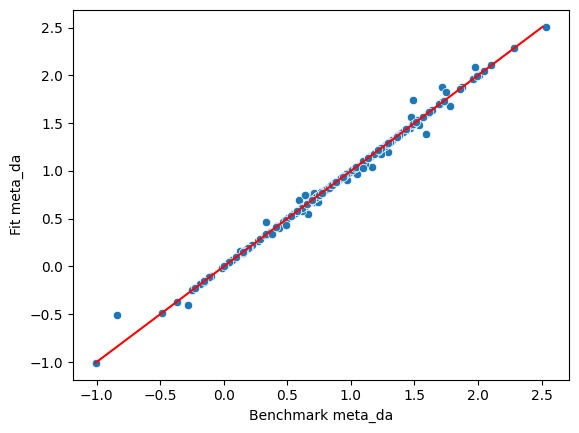

In [98]:
# plot benachmark results vs fit results
plt.figure()
plot_data = total_results.merge(bf, left_on="subject", right_on="user_id")
sns.scatterplot(data=plot_data, x="meta_da", y="fit_meta_d")
minimum = np.maximum(plot_data["fit_meta_d"].min(), plot_data["meta_da"].min())
maximum = np.minimum(plot_data["fit_meta_d"].max(), plot_data["meta_da"].max())
plt.plot([minimum, maximum], [minimum, maximum], color="red")
plt.xlabel("Benchmark meta_da")
plt.ylabel("Fit meta_da")
plt.show()